In [1]:
import numpy as np
import pandas as pd
import pickle

import sklearn
import sklearn.preprocessing
import sklearn.model_selection

import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm import tqdm
import time

from matplotlib import pyplot as plt
import os
from copy import deepcopy

from models import *

In [2]:
with open('data/current.pkl', 'rb') as file:
    df_current = pickle.load(file)

with open('data/parameters.pkl', 'rb') as file:
    df_params = pickle.load(file)

In [3]:
df_params = df_params.rename(columns={"membrane": "diaphragm", "WW": "circuit function", "nominal width": "nominal width in mm", "voltage": "voltage in V", "pvor": "p_supply in bar", "prueck": "p_back in bar"})
df_params['nominal width in mm'] = df_params['nominal width in mm'].str.replace(',', '.').astype('float')
df_params['voltage in V'] = df_params['voltage in V'].astype('float')
df_params['p_supply in bar'] = df_params['p_supply in bar'].astype('float')
df_params['p_back in bar'] = df_params['p_back in bar'].astype('float')
df_params['ID'] = df_params['ID'].astype('int')

In [4]:
X = df_current.values
y = df_params['diaphragm'].copy()

In [5]:
enc = sklearn.preprocessing.OneHotEncoder(categories=[['AA', 'FF', 'CC']], sparse=False)
y_ohe = enc.fit_transform(y.values.reshape(-1, 1))
y_ohe

array([[0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       ...,
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [6]:
# Random Train-test split
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y_ohe, test_size=0.2, random_state=42)#, stratify=y_ohe)

In [7]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

In [8]:
cat_weights = torch.tensor([1.,4.,1.],dtype=torch.float32, device=device)

In [9]:
model = PDEInspiredModel(ts_model=CurrentFlowPrediction,model_channels=5)
model = model.to(device)
model(torch.tensor(X_train[:1],dtype=torch.float32, device=device))

tensor([[0.3836, 0.2443, 0.3722]], grad_fn=<SoftmaxBackward0>)

In [10]:
X_fit, X_val, y_fit, y_val = sklearn.model_selection.train_test_split(X_train, y_train, test_size=0.30, random_state=123)#, stratify=y_ohe)

history = model.fit(X_fit, y_fit, X_val, y_val, cat_weights=cat_weights)

parameter count: 204

saving model

1.153006556897651e-08
epoch 0, loss=1.5985798835754395, val. loss=1.4614064693450928, val. acc.=0.1059730276465416, time: 679ms
0.0
epoch 1, loss=1.5565776228904724, val. loss=1.49692964553833, val. acc.=0.1059730276465416, time: 614ms
1.56763080294553e-09
epoch 2, loss=1.5367104411125183, val. loss=1.4675639867782593, val. acc.=0.1059730276465416, time: 586ms
0.0
epoch 3, loss=1.5322679281234741, val. loss=1.4409680366516113, val. acc.=0.1059730276465416, time: 590ms
8.503058479547576e-09
epoch 4, loss=1.5307906866073608, val. loss=1.4320307970046997, val. acc.=0.1059730276465416, time: 585ms

saving model

0.0
epoch 5, loss=1.526799201965332, val. loss=1.4293370246887207, val. acc.=0.5125240683555603, time: 637ms
5.712996298257167e-09
epoch 6, loss=1.5057513117790222, val. loss=1.4215940237045288, val. acc.=0.18111753463745117, time: 599ms
0.0
epoch 7, loss=1.4917887449264526, val. loss=1.4122498035430908, val. acc.=0.1059730276465416, time: 605ms


2.2314036868920084e-05
epoch 64, loss=0.44910867512226105, val. loss=0.4334038496017456, val. acc.=0.8978805541992188, time: 625ms
6.917063728906214e-05
epoch 65, loss=0.4603670835494995, val. loss=0.46862703561782837, val. acc.=0.7976878881454468, time: 622ms
0.0001533481909063994
epoch 66, loss=0.43780645728111267, val. loss=0.4320566952228546, val. acc.=0.9017341136932373, time: 615ms
0.0
epoch 67, loss=0.45229922235012054, val. loss=0.4711742699146271, val. acc.=0.799614667892456, time: 600ms
1.3074724847683683e-05
epoch 68, loss=0.44002939760684967, val. loss=0.4236701428890228, val. acc.=0.8747591376304626, time: 618ms
0.00011080007971031591
epoch 69, loss=0.445371612906456, val. loss=0.41069263219833374, val. acc.=0.8921002149581909, time: 620ms
0.00012853489897679538
epoch 70, loss=0.421386256814003, val. loss=0.44066110253334045, val. acc.=0.8265895843505859, time: 625ms
8.745735613047145e-05
epoch 71, loss=0.42840929329395294, val. loss=0.4021073579788208, val. acc.=0.9017341

0.00040437046118313447
epoch 127, loss=0.260496087372303, val. loss=0.28513672947883606, val. acc.=0.913294792175293, time: 571ms
0.0010124059408553876
epoch 128, loss=0.2672477513551712, val. loss=0.2774098813533783, val. acc.=0.9190751314163208, time: 573ms
0.00023095009964890778
epoch 129, loss=0.25834134221076965, val. loss=0.28590548038482666, val. acc.=0.9055876731872559, time: 586ms
0.0012031766818836331
epoch 130, loss=0.25264932215213776, val. loss=0.27174580097198486, val. acc.=0.9171483516693115, time: 570ms
0.0006012844678480178
epoch 131, loss=0.24882777780294418, val. loss=0.2739408016204834, val. acc.=0.9210019111633301, time: 566ms
0.0
epoch 132, loss=0.26434074342250824, val. loss=0.30053776502609253, val. acc.=0.8824662566184998, time: 570ms
0.0
epoch 133, loss=0.2725033164024353, val. loss=0.2779812812805176, val. acc.=0.9190751314163208, time: 566ms
0.0002310037234565243
epoch 134, loss=0.2601064667105675, val. loss=0.2885047495365143, val. acc.=0.8882466554641724, 

0.002551906043663621
epoch 190, loss=0.1930682584643364, val. loss=0.21671819686889648, val. acc.=0.9325626492500305, time: 584ms
0.00612193180131726
epoch 191, loss=0.17603369802236557, val. loss=0.2073480784893036, val. acc.=0.9460501074790955, time: 560ms
0.007623620796948671
epoch 192, loss=0.18009816855192184, val. loss=0.21293458342552185, val. acc.=0.9344894289970398, time: 567ms
0.0019494438311085105
epoch 193, loss=0.19158371537923813, val. loss=0.212322399020195, val. acc.=0.9364162087440491, time: 588ms
0.0035981413384433836
epoch 194, loss=0.19167586416006088, val. loss=0.20515133440494537, val. acc.=0.9383429884910583, time: 572ms
0.004346636560512707
epoch 195, loss=0.17634554207324982, val. loss=0.20909501612186432, val. acc.=0.9402697682380676, time: 561ms
0.0021962488535791636
epoch 196, loss=0.18995746970176697, val. loss=0.20080424845218658, val. acc.=0.9518304467201233, time: 582ms
0.003395786974579096
epoch 197, loss=0.19184008985757828, val. loss=0.227659747004508

0.002135033020749688
epoch 253, loss=0.18410886079072952, val. loss=0.1909308284521103, val. acc.=0.9460501074790955, time: 573ms
0.00027458916883915663
epoch 254, loss=0.17124560475349426, val. loss=0.18289144337177277, val. acc.=0.9479768872261047, time: 568ms
0.008215937647037208
epoch 255, loss=0.18672467023134232, val. loss=0.203809916973114, val. acc.=0.9364162087440491, time: 582ms
9.107595542445779e-05
epoch 256, loss=0.18664585053920746, val. loss=0.17820121347904205, val. acc.=0.9614643454551697, time: 566ms
0.014104967005550861
epoch 257, loss=0.1746012642979622, val. loss=0.2144409716129303, val. acc.=0.9325626492500305, time: 557ms
0.0026393872685730457
epoch 258, loss=0.17909575253725052, val. loss=0.1848096251487732, val. acc.=0.9691714644432068, time: 590ms
0.009732495993375778
epoch 259, loss=0.1717119961977005, val. loss=0.18026557564735413, val. acc.=0.9556840062141418, time: 563ms
0.006584801594726741
epoch 260, loss=0.2007918730378151, val. loss=0.17413076758384705

...

0.017953598871827126
epoch 9727, loss=0.016282973811030388, val. loss=0.026585891842842102, val. acc.=0.9942196607589722, time: 598ms
0.014921572292223573
epoch 9728, loss=0.01536985905840993, val. loss=0.026908712461590767, val. acc.=0.9942196607589722, time: 585ms
0.014294357039034367
epoch 9729, loss=0.013773218728601933, val. loss=0.02712276019155979, val. acc.=0.9942196607589722, time: 576ms
0.0075249201618134975
epoch 9730, loss=0.016290913335978985, val. loss=0.029745381325483322, val. acc.=0.9942196607589722, time: 598ms
0.0027736190240830183
epoch 9731, loss=0.015576410107314587, val. loss=0.028675302863121033, val. acc.=0.9942196607589722, time: 576ms
0.044423267245292664
epoch 9732, loss=0.013656288851052523, val. loss=0.02443617954850197, val. acc.=0.9942196607589722, time: 605ms
0.3921247273683548
epoch 9733, loss=0.017796264961361885, val. loss=0.03005078248679638, val. acc.=0.9942196607589722, time: 576ms
0.19837350398302078
epoch 9734, loss=0.012824742589145899, val. lo

0.06571143213659525
epoch 9790, loss=0.016115025617182255, val. loss=0.026842666789889336, val. acc.=0.9942196607589722, time: 593ms
0.045815645600669086
epoch 9791, loss=0.01673963200300932, val. loss=0.03357115015387535, val. acc.=0.9942196607589722, time: 596ms
0.06487771641695872
epoch 9792, loss=0.016171300318092108, val. loss=0.027014879509806633, val. acc.=0.9942196607589722, time: 580ms
0.018512465059757233
epoch 9793, loss=0.01182038290426135, val. loss=0.025895459577441216, val. acc.=0.9942196607589722, time: 578ms
0.38231173902750015
epoch 9794, loss=0.011899695731699467, val. loss=0.03731289878487587, val. acc.=0.9922928810119629, time: 574ms
0.0012204499216750264
epoch 9795, loss=0.013275469187647104, val. loss=0.02814706787467003, val. acc.=0.9942196607589722, time: 583ms
0.049888092558830976
epoch 9796, loss=0.017428715713322163, val. loss=0.026921892538666725, val. acc.=0.9942196607589722, time: 581ms
0.25010281056165695
epoch 9797, loss=0.009354580659419298, val. loss=

0.0
epoch 9854, loss=0.01636120304465294, val. loss=0.025886202231049538, val. acc.=0.9942196607589722, time: 594ms
0.0034288472961634398
epoch 9855, loss=0.013322639744728804, val. loss=0.02622765488922596, val. acc.=0.9942196607589722, time: 588ms
0.05914666410535574
epoch 9856, loss=0.010535375215113163, val. loss=0.028695132583379745, val. acc.=0.9942196607589722, time: 614ms
0.0
epoch 9857, loss=0.01582543272525072, val. loss=0.03099633753299713, val. acc.=0.9942196607589722, time: 593ms
0.0317252348177135
epoch 9858, loss=0.015132480300962925, val. loss=0.02569315768778324, val. acc.=0.9942196607589722, time: 589ms
0.13172142207622528
epoch 9859, loss=0.015218005515635014, val. loss=0.02317574992775917, val. acc.=0.9942196607589722, time: 587ms
0.0
epoch 9860, loss=0.014902264345437288, val. loss=0.027040639892220497, val. acc.=0.9942196607589722, time: 587ms
0.24129363894462585
epoch 9861, loss=0.012569695245474577, val. loss=0.030448246747255325, val. acc.=0.9942196607589722, t

0.007490369025617838
epoch 9918, loss=0.016020391136407852, val. loss=0.03375890851020813, val. acc.=0.9942196607589722, time: 615ms
0.007074887398630381
epoch 9919, loss=0.01617238810285926, val. loss=0.02928493171930313, val. acc.=0.9942196607589722, time: 605ms
0.05527174100279808
epoch 9920, loss=0.012813976034522057, val. loss=0.030179338529706, val. acc.=0.9942196607589722, time: 606ms
0.1554369181394577
epoch 9921, loss=0.01475890725851059, val. loss=0.029395559802651405, val. acc.=0.9942196607589722, time: 585ms
0.0
epoch 9922, loss=0.01358071668073535, val. loss=0.0321170836687088, val. acc.=0.9942196607589722, time: 611ms
0.09212576597929001
epoch 9923, loss=0.015871162991970778, val. loss=0.03348870575428009, val. acc.=0.9942196607589722, time: 587ms
0.004567071795463562
epoch 9924, loss=0.013417043257504702, val. loss=0.029626330360770226, val. acc.=0.9942196607589722, time: 584ms
0.2172234207391739
epoch 9925, loss=0.014691198710352182, val. loss=0.026420824229717255, val.

0.007458179257810116
epoch 9982, loss=0.012559545692056417, val. loss=0.0315542034804821, val. acc.=0.9942196607589722, time: 606ms
0.02876397781074047
epoch 9983, loss=0.013476281426846981, val. loss=0.024550307542085648, val. acc.=0.9942196607589722, time: 589ms
0.09806442074477673
epoch 9984, loss=0.014845459256321192, val. loss=0.026082385331392288, val. acc.=0.9942196607589722, time: 618ms
0.029064681380987167
epoch 9985, loss=0.015556872822344303, val. loss=0.03133365884423256, val. acc.=0.9942196607589722, time: 605ms
0.058503683656454086
epoch 9986, loss=0.013854903168976307, val. loss=0.03605061396956444, val. acc.=0.9942196607589722, time: 612ms
0.10327214654535055
epoch 9987, loss=0.018000520765781403, val. loss=0.025013361126184464, val. acc.=0.9942196607589722, time: 617ms
0.036406582687050104
epoch 9988, loss=0.014462161343544722, val. loss=0.029576072469353676, val. acc.=0.9942196607589722, time: 585ms
0.0
epoch 9989, loss=0.017916002310812473, val. loss=0.03351347520947

In [11]:
model.load_state_dict(torch.load(('./pde_model.pt')))

<All keys matched successfully>

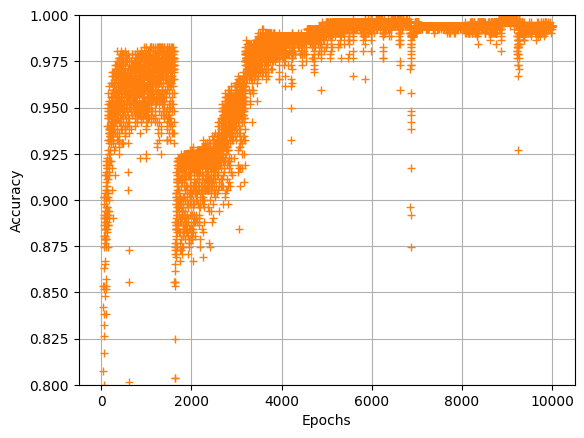

In [12]:
# acc = history.history['accuracy']
val_acc = np.array(history)[:,2]
epochs = range(1, len(val_acc) + 1)

# plt.plot(epochs, acc, 'b+')
plt.plot(epochs, val_acc, '+',color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim((0.8,1))
plt.grid()
plt.show()

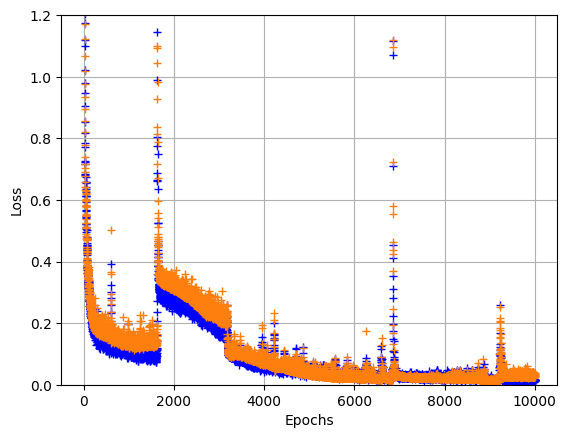

In [13]:
loss_values = np.array(history)[:,0]
val_loss_values = np.array(history)[:,1]
epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'b+')
plt.plot(epochs, val_loss_values, '+',color='tab:orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.ylim((0.,1.2))
plt.grid()
plt.show()

In [14]:
y_cv = model(torch.tensor(X_train, dtype=torch.float32)).detach().numpy()

In [15]:
new = np.zeros(y_cv.shape)
for i, j in enumerate(y_cv):
    new[i][np.argmax(j)] = 1

y_cv_class = new.astype('int')
y_cv_class

array([[1, 0, 0],
       [0, 0, 1],
       [1, 0, 0],
       ...,
       [1, 0, 0],
       [0, 1, 0],
       [1, 0, 0]])

In [16]:
# Calculate scores
r2_score_train = sklearn.metrics.r2_score(y_train, y_cv_class)
ev_score_train = sklearn.metrics.explained_variance_score(y_train, y_cv_class)
mse_train = sklearn.metrics.mean_squared_error(y_train, y_cv_class)
acc_score_train = sklearn.metrics.accuracy_score(y_train, y_cv_class)
precision_score_train_None = sklearn.metrics.precision_score(y_train, y_cv_class, average=None)
recall_score_train_None = sklearn.metrics.recall_score(y_train, y_cv_class, average=None)
precision_score_train_macro = sklearn.metrics.precision_score(y_train, y_cv_class, average='macro')
recall_score_train_macro= sklearn.metrics.recall_score(y_train, y_cv_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_train))
print(f"Precision: {np.array2string(precision_score_train_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_train_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_train_macro}")
print(f"Recall macro: {recall_score_train_macro}")

R2 Score: 0.9953
Explained variance score: 0.9953
Mean squared error: 0.0012
Accuracy Score: 0.9983
Precision: [0.9958 1.0000 1.0000]
Recall: [1.0000 1.0000 0.9962]
Precision macro: 0.9985974754558206
Recall macro: 0.9987468671679198


### Train quality

In [17]:
class_number = len(y_cv_class[0])
cm_train = np.zeros((class_number, class_number))
for tr, pre in zip(y_train, y_cv_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_train[i_true][i_pred] += 1
    
cm_train

array([[710.,   0.,   0.],
       [  0., 221.,   0.],
       [  3.,   0., 795.]])

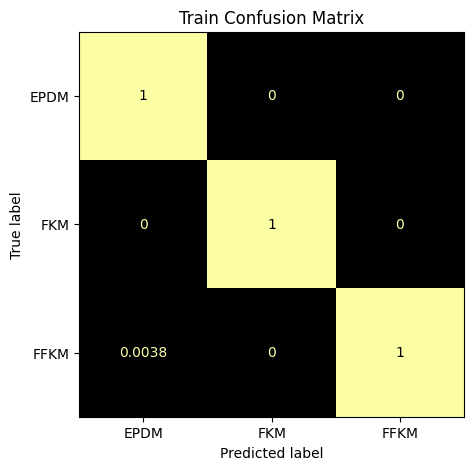

In [18]:
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_train[0] / cm_train[0].sum(), 
                                                        cm_train[1] / cm_train[1].sum(), 
                                                        cm_train[2] / cm_train[2].sum()]), 
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Train Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

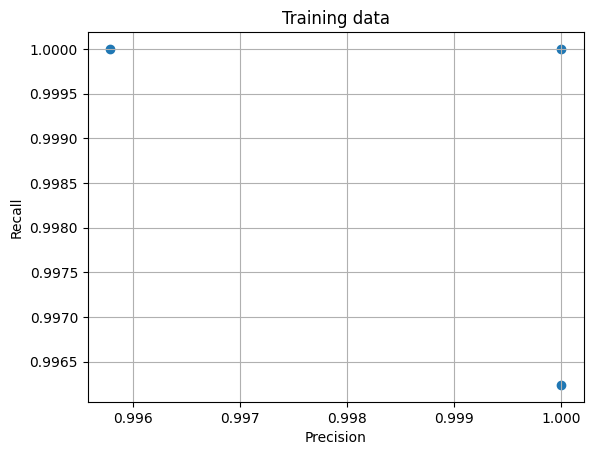

In [19]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_train_None[0],3))+'\n'+str(round(recall_score_train_None[0],3)),
     'FKM\n'+str(round(precision_score_train_None[1],3))+'\n'+str(round(recall_score_train_None[1],3)), 
     'FFKM\n'+str(round(precision_score_train_None[2],3))+'\n'+str(round(recall_score_train_None[2],3))]

ax.scatter(precision_score_train_None, recall_score_train_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Training data')

ax.annotate(n[0], (precision_score_train_None[0]+0.0015, recall_score_train_None[0]-0.009)) # EPDM
ax.annotate(n[1], (precision_score_train_None[1]+0.0015, recall_score_train_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_train_None[2]-0.008, recall_score_train_None[2]-0.011)) # FFKM
plt.show()

## Test model

In [20]:
y_predict = model(torch.tensor(X_test,dtype=torch.float32)).detach().numpy()
y_predict

array([[1.0000000e+00, 8.3611456e-09, 1.3327113e-09],
       [9.9662411e-01, 9.7595781e-05, 3.2783847e-03],
       [3.7464949e-06, 9.1797264e-11, 9.9999630e-01],
       ...,
       [4.1500125e-06, 7.3394613e-10, 9.9999583e-01],
       [1.2646262e-07, 9.9999988e-01, 2.2764714e-10],
       [2.0327323e-06, 8.4050311e-10, 9.9999797e-01]], dtype=float32)

### Test metrics

In [21]:
new = np.zeros(y_predict.shape)
for i, j in enumerate(y_predict): # enumerate, itterieren durch Liste i = index, j = Wert
    new[i][np.argmax(j)] = 1

y_predict_class = new.astype('int')
y_predict_class

array([[1, 0, 0],
       [1, 0, 0],
       [0, 0, 1],
       ...,
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1]])

In [22]:
# Calculate scores
r2_score_test = sklearn.metrics.r2_score(y_test, y_predict_class)
ev_score_test = sklearn.metrics.explained_variance_score(y_test, y_predict_class)
mse_test = sklearn.metrics.mean_squared_error(y_test, y_predict_class)
acc_score_test = sklearn.metrics.accuracy_score(y_test, y_predict_class)
precision_score_test_None = sklearn.metrics.precision_score(y_test, y_predict_class, average=None)
recall_score_test_None = sklearn.metrics.recall_score(y_test, y_predict_class, average=None)
precision_score_test_macro = sklearn.metrics.precision_score(y_test, y_predict_class, average='macro')
recall_score_test_macro= sklearn.metrics.recall_score(y_test, y_predict_class, average='macro')

print("R2 Score: {:.4f}".format(r2_score_train))
print("Explained variance score: {:.4f}".format(ev_score_train))
print("Mean squared error: {:.4f}".format(mse_train))
print("Accuracy Score: {:.4f}".format(acc_score_test))
print(f"Precision: {np.array2string(precision_score_test_None, precision=4, floatmode='fixed')}")
print(f"Recall: {np.array2string(recall_score_test_None, precision=4, floatmode='fixed')}")
print(f"Precision macro: {precision_score_test_macro}")
print(f"Recall macro: {recall_score_test_macro}")

R2 Score: 0.9953
Explained variance score: 0.9953
Mean squared error: 0.0012
Accuracy Score: 0.9931
Precision: [0.9944 0.9574 1.0000]
Recall: [0.9944 1.0000 0.9904]
Precision macro: 0.9839534054439558
Recall macro: 0.9949480099435993


### Test quality

In [23]:
class_number = len(y_predict_class[0])
cm_test = np.zeros((class_number, class_number))
for tr, pre in zip(y_test, y_predict_class):
    i_true = np.argmax(tr)
    i_pred = np.argmax(pre)
    cm_test[i_true][i_pred] += 1
    
cm_test

array([[178.,   1.,   0.],
       [  0.,  45.,   0.],
       [  1.,   1., 207.]])

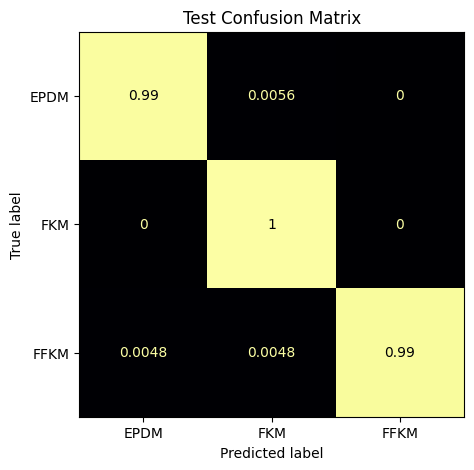

In [24]:
# sklearn.metrics.ConfusionMatrixDisplay(cm_train).plot()
fig, ax = plt.subplots(1, 1, figsize=[5, 5])

disp = sklearn.metrics.ConfusionMatrixDisplay(np.array([cm_test[0] / cm_test[0].sum(), 
                                                 cm_test[1] / cm_test[1].sum(), 
                                                 cm_test[2] / cm_test[2].sum()]),
                                              display_labels=['EPDM', 'FKM', 'FFKM'])

ax.set_title('Test Confusion Matrix')
disp.plot(cmap='inferno', ax=ax, colorbar=False) # cmap: https://matplotlib.org/stable/tutorials/colors/colormaps.html
plt.show()

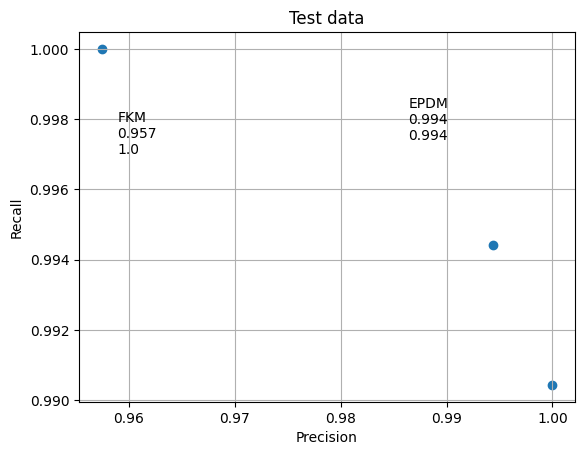

In [25]:
fig, ax = plt.subplots(1, 1)#, figsize=[5, 5])
n = ['EPDM\n'+str(round(precision_score_test_None[0],3))+'\n'+str(round(recall_score_test_None[0],3)),
     'FKM\n'+str(round(precision_score_test_None[1],3))+'\n'+str(round(recall_score_test_None[1],3)), 
     'FFKM\n'+str(round(precision_score_test_None[2],3))+'\n'+str(round(recall_score_test_None[2],3))]

ax.scatter(precision_score_test_None, recall_score_test_None)
ax.grid()
ax.set_xlabel('Precision')
ax.set_ylabel('Recall')
ax.set_title('Test data')

ax.annotate(n[0], (precision_score_test_None[0]-0.008, recall_score_test_None[0]+0.003)) # EPDM
ax.annotate(n[1], (precision_score_test_None[1]+0.0015, recall_score_test_None[1]-0.003)) # FKM
ax.annotate(n[2], (precision_score_test_None[2]-0.008, recall_score_test_None[2]-0.008)) # FFKM
plt.show()

In [27]:
# torch.save(deepcopy(model.state_dict()), 'CurrentFlowModel.pt')